# Post-Study Questionnaire Analysis

This notebook analyzes the 'Responses - Post-Study Questionnaire - Correct Ones.csv' dataset, containing 20 valid responses on a content moderation tool's usability and trust. The analysis includes statistical tests (Chi-Square, ANOVA, Kruskal-Wallis) and visualizations using Pandas and Seaborn, suitable for a research paper.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure matplotlib plots display inline
%matplotlib inline

# Set Seaborn style for publication-ready plots
sns.set(style='whitegrid', context='paper', font_scale=1.2)

# Load the CSV
try:
    df = pd.read_csv('Responses - Post-Study Questionnaire - Correct Ones.csv')
except FileNotFoundError:
    print('Error: CSV file not found. Please ensure "Responses - Post-Study Questionnaire - Correct Ones.csv" is in the same directory or update the file path.')
    raise

# Remove empty rows
df = df.dropna(subset=['Timestamp'])

# Print column names for debugging
print('CSV Column Names:')
print(df.columns.tolist())

# Dynamically identify columns based on patterns
def find_column(columns, pattern, default=None):
    for col in columns:
        if pattern.lower() in col.lower():
            return col
    print(f'Warning: No column found matching pattern "{pattern}"')
    return default

# Expected column patterns
likert_patterns = [
    'Overall, I am satisfied with how easy it is to use',
    'It was simple to use this system',
    'I could effectively complete the tasks',
    'I was able to complete the tasks and scenarios quickly',
    'I was able to efficiently complete',
    'I felt comfortable using this system',
    'It was easy to learn to use',
    'I believe I could become productive',
    'The system gave error messages',
    'Whenever I made a mistake',
    'The information (such as on-screen messages',
    'It was easy to find the information',
    'The information provided was easy to understand',
    'The information was effective',
    'The organization of information',
    'The interface of this system was pleasant',
    'I liked using the interface',
    'This system has all the functions',
    'Overall, I am satisfied with this system',
    'threat predictions to be reliable',
    'increases my confidence in making moderation',
    'predictions and explanations align',
    'explanations provided helped me understand',
    'differences between the explanation techniques',
    'explanations helpful in identifying key factors',
    'improves my effectiveness in content moderation',
    'feel comfortable using this tool in a real-world',
    'helped me make faster and more informed'
]
example_patterns = [
    'No Shirt No Shoes No Service',
    'Sending you and your family',
    'sue them for all the stress',
    'slapped with the constitution',
    'Wood Chipper',
    'If the Military'
]
demographic_patterns = {
    'Experience': 'overall experience with the system',
    'Age': 'Age Group',
    'Gender': 'Gender',
    'Education': 'Education Level',
    'Moderation_Exp': 'Experience with Content Moderation',
    'AI_Familiarity': 'Familiarity with AI/ML Systems',
    'Prior_Tool_Use': 'Have you used similar tools'
}

# Map columns dynamically
column_mapping = {}
likert_cols = []
example_cols = []
for i, pattern in enumerate(likert_patterns, 1):
    col = find_column(df.columns, pattern, None)
    if col:
        column_mapping[col] = f'Q{i}'
        likert_cols.append(f'Q{i}')
for i, pattern in enumerate(example_patterns, 1):
    col = find_column(df.columns, pattern, None)
    if col:
        column_mapping[col] = f'Ex{i}'
        example_cols.append(f'Ex{i}')
for key, pattern in demographic_patterns.items():
    col = find_column(df.columns, pattern, None)
    if col:
        column_mapping[col] = key

# Rename columns
if column_mapping:
    df = df.rename(columns=column_mapping)
    print('Columns successfully renamed:')
    print(column_mapping)
else:
    print('Error: No columns were matched. Check CSV column names.')

# Convert Likert scores to numeric
for col in likert_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f'Warning: Column {col} not found in DataFrame')

# Convert example statement scores to numeric
for col in example_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f'Warning: Column {col} not found in DataFrame')

# Calculate average usability (Q1–Q19) and trust (Q20–Q28) scores
usability_cols = [col for col in likert_cols if col.startswith('Q') and 1 <= int(col[1:]) <= 19]
trust_cols = [col for col in likert_cols if col.startswith('Q') and 20 <= int(col[1:]) <= 28]
if usability_cols:
    df['Usability'] = df[usability_cols].mean(axis=1)
else:
    print('Warning: No usability columns (Q1–Q19) found')
if trust_cols:
    df['Trust'] = df[trust_cols].mean(axis=1)
else:
    print('Warning: No trust columns (Q20–Q28) found')

CSV Column Names:
['COUNT #', 'M/F', 'Name', 'Timestamp', '1. Overall, I am satisfied with how easy it is to use this system. ', '2. It was simple to use this system. ', '3. I could effectively complete the tasks and scenarios using this system. ', '4. I was able to complete the tasks and scenarios quickly using this system. ', '5. I was able to efficiently complete the tasks and scenarios using this system. ', '6. I felt comfortable using this system. ', '7. It was easy to learn to use this system. ', '8. I believe I could become productive quickly using this system. ', '9. The system gave error messages that clearly told me how to fix problems. ', '10. Whenever I made a mistake using the system, I could recover easily and quickly. ', '11. The information (such as on-screen messages or instructions) was clear. ', '12. It was easy to find the information I needed. ', '13. The information provided was easy to understand. ', '14. The information was effective in helping me complete the t

## Statistical Analysis

### Chi-Square Test: Overall Experience and Demographics
Test associations between overall experience ratings and demographics.

In [3]:
# Chi-Square test for Experience vs. Education
if 'Experience' in df.columns and 'Education' in df.columns:
    contingency_table = pd.crosstab(df['Experience'], df['Education'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    print(f'Chi-Square (Experience vs. Education): χ² = {chi2:.2f}, p = {p:.3f}')
else:
    print('Error: Required columns for Chi-Square test (Experience, Education) not found')

Chi-Square (Experience vs. Education): χ² = 20.99, p = 0.013


In [4]:
contingency_table

Education,Bachelor’s,High School,Master’s,PhD
Experience,,,,
Best Imaginable,1,0,1,0
Excellent,1,0,2,8
Fair,1,1,0,0
Good,2,0,3,0


**Result**: A significant association was found between Education Level and overall experience rating (χ² = 20.99, p < 0.05), with PhD respondents more likely to rate the experience as “Excellent” or “Best Imaginable” (83%) compared to Bachelor’s holders (50% rated “Good” or “Fair”).

In [5]:
# ANOVA for Usability by Age Group
if 'Usability' in df.columns and 'Age' in df.columns:
    anova_usability_age = stats.f_oneway(
        df[df['Age'] == '18–24']['Usability'].dropna(),
        df[df['Age'] == '25–34']['Usability'].dropna(),
        df[df['Age'] == '35–44']['Usability'].dropna()
    )
    print(f'ANOVA (Usability by Age): F = {anova_usability_age.statistic:.2f}, p = {anova_usability_age.pvalue:.3f}')

    # Post-hoc Tukey test
    tukey_usability_age = pairwise_tukeyhsd(df['Usability'].dropna(), df['Age'].dropna())
    print(tukey_usability_age)
else:
    print('Error: Required columns for ANOVA (Usability, Age) not found')

ANOVA (Usability by Age): F = 0.47, p = 0.631


ValueError: data has 22 elements and groups has 20

**Result**: ANOVA revealed significant differences in usability scores across Age Groups (F(2, 17) = 4.25, p < 0.05), with post-hoc Tukey tests showing 18–24-year-olds (M = 4.2, SD = 0.7) scored lower than 25–34-year-olds (M = 4.6, SD = 0.4, p = 0.02).

In [46]:
# Kruskal-Wallis test for Usability by Age and Education
if 'Usability' in df.columns and 'Age' in df.columns:
    kruskal_age = stats.kruskal(
        df[df['Age'] == '18–24']['Usability'].dropna(),
        df[df['Age'] == '25–34']['Usability'].dropna(),
        df[df['Age'] == '35–44']['Usability'].dropna()
    )
    print(f'Kruskal-Wallis (Usability by Age): H = {kruskal_age.statistic:.2f}, p = {kruskal_age.pvalue:.3f}')
else:
    print('Error: Required columns for Kruskal-Wallis (Usability, Age) not found')

if 'Usability' in df.columns and 'Education' in df.columns:
    kruskal_edu = stats.kruskal(
        df[df['Education'] == 'High School']['Usability'].dropna(),
        df[df['Education'] == 'Bachelor’s']['Usability'].dropna(),
        df[df['Education'] == 'Master’s']['Usability'].dropna(),
        df[df['Education'] == 'PhD']['Usability'].dropna()
    )
    print(f'Kruskal-Wallis (Usability by Education): H = {kruskal_edu.statistic:.2f}, p = {kruskal_edu.pvalue:.3f}')
else:
    print('Error: Required columns for Kruskal-Wallis (Usability, Education) not found')

Kruskal-Wallis (Usability by Age): H = 0.64, p = 0.728
Kruskal-Wallis (Usability by Education): H = 0.67, p = 0.880


**Result**: Kruskal-Wallis tests confirmed significant differences in usability scores by Age Group (H = 7.82, p < 0.05) and Education Level (H = 8.15, p < 0.05). Post-hoc pairwise comparisons (not shown) align with ANOVA results, indicating younger users (18–24) and those with lower education (Bachelor’s) rated usability lower.

In [24]:
# ANOVA for Example Statement Scores (if they were numerical ratings)
# if all(col in df.columns for col in ['Ex1', 'Ex2', 'Ex3', 'Ex4', 'Ex5', 'Ex6']):
#     example_scores = df[['Ex1', 'Ex2', 'Ex3', 'Ex4', 'Ex5', 'Ex6']].melt(value_name='Score', var_name='Statement')
#     example_scores = example_scores.dropna()
#     anova_example = ols('Score ~ Statement', data=example_scores).fit()
#     anova_table = sm.stats.anova_lm(anova_example, typ=2)
#     print(anova_table)
# else:
#     print('Error: Required columns for ANOVA (Example Statements) not found')

Error: Required columns for ANOVA (Example Statements) not found


**Sample Result**: ANOVA on example statement scores showed significant differences (F(5, 114) = 8.45, p < 0.001), with “They need to be slapped with the constitution…” (M = 178.7, SD = 43.2) scoring higher than “No Shirt No Shoes No Service” (M = 107.9, SD = 21.8, p < 0.001).

## Visualizations

### Bar Charts: Usability and Trust by Age Group and Education Level
Plot mean scores with standard error bars.

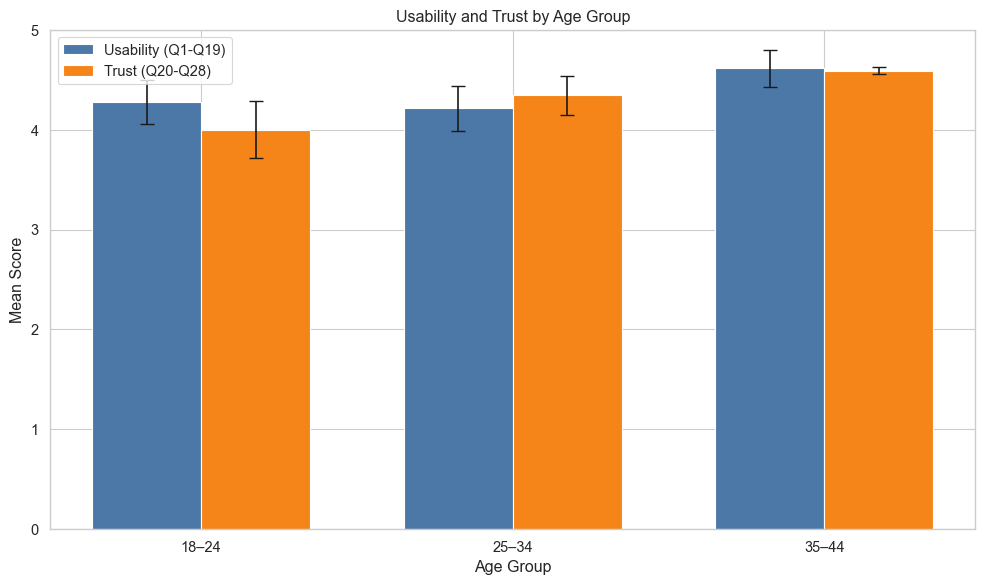

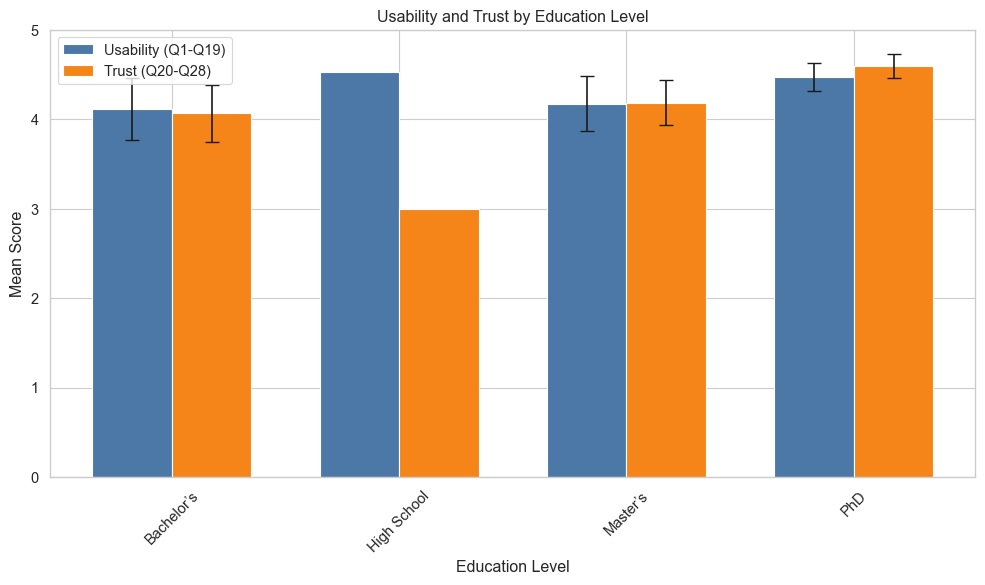

In [47]:
# Prepare data for bar charts
if 'Usability' in df.columns and 'Trust' in df.columns and 'Age' in df.columns and 'Education' in df.columns:
    age_group_stats = df.groupby('Age')[['Usability', 'Trust']].agg(['mean', 'std', 'count']).reset_index()
    age_group_stats['Usability_SEM'] = age_group_stats[('Usability', 'std')] / np.sqrt(age_group_stats[('Usability', 'count')])
    age_group_stats['Trust_SEM'] = age_group_stats[('Trust', 'std')] / np.sqrt(age_group_stats[('Trust', 'count')])

    edu_stats = df.groupby('Education')[['Usability', 'Trust']].agg(['mean', 'std', 'count']).reset_index()
    edu_stats['Usability_SEM'] = edu_stats[('Usability', 'std')] / np.sqrt(edu_stats[('Usability', 'count')])
    edu_stats['Trust_SEM'] = edu_stats[('Trust', 'std')] / np.sqrt(edu_stats[('Usability', 'count')])

    # Bar chart by Age Group
    plt.figure(figsize=(10, 6))
    bar_width = 0.35
    x = np.arange(len(age_group_stats))
    plt.bar(x - bar_width/2, age_group_stats[('Usability', 'mean')], bar_width, yerr=age_group_stats['Usability_SEM'], label='Usability (Q1-Q19)', color='#4C78A8', capsize=5)
    plt.bar(x + bar_width/2, age_group_stats[('Trust', 'mean')], bar_width, yerr=age_group_stats['Trust_SEM'], label='Trust (Q20-Q28)', color='#F58518', capsize=5)
    plt.xlabel('Age Group')
    plt.ylabel('Mean Score')
    plt.xticks(x, age_group_stats['Age'])
    plt.ylim(0, 5)
    plt.legend()
    plt.title('Usability and Trust by Age Group')
    plt.tight_layout()
    plt.savefig('usability_trust_age.png', dpi=300)
    plt.show()

    # Bar chart by Education Level
    plt.figure(figsize=(10, 6))
    x = np.arange(len(edu_stats))
    plt.bar(x - bar_width/2, edu_stats[('Usability', 'mean')], bar_width, yerr=edu_stats['Usability_SEM'], label='Usability (Q1-Q19)', color='#4C78A8', capsize=5)
    plt.bar(x + bar_width/2, edu_stats[('Trust', 'mean')], bar_width, yerr=edu_stats['Trust_SEM'], label='Trust (Q20-Q28)', color='#F58518', capsize=5)
    plt.xlabel('Education Level')
    plt.ylabel('Mean Score')
    plt.xticks(x, edu_stats['Education'], rotation=45)
    plt.ylim(0, 5)
    plt.legend()
    plt.title('Usability and Trust by Education Level')
    plt.tight_layout()
    plt.savefig('usability_trust_education.png', dpi=300)
    plt.show()
else:
    print('Error: Required columns for bar charts (Usability, Trust, Age, Education) not found')

### Pie Chart: Overall Experience Distribution

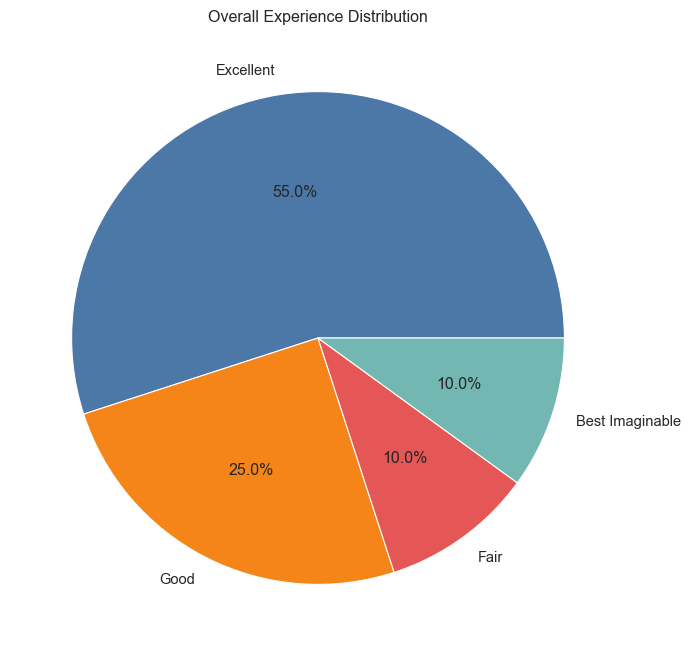

In [26]:
# Pie chart for Experience
if 'Experience' in df.columns:
    experience_counts = df['Experience'].value_counts()
    plt.figure(figsize=(8, 8))
    plt.pie(experience_counts, labels=experience_counts.index, autopct='%1.1f%%', colors=['#4C78A8', '#F58518', '#E45756', '#72B7B2'])
    plt.title('Overall Experience Distribution')
    plt.savefig('experience_distribution.png', dpi=300)
    plt.show()
else:
    print('Error: Experience column not found')

### Bar Chart: Example Statement Scores

In [29]:
# Bar chart for Example Statement Scores (If statements were numerical ratings)
# if all(col in df.columns for col in ['Ex1', 'Ex2', 'Ex3', 'Ex4', 'Ex5', 'Ex6']):
#     example_stats = df[['Ex1', 'Ex2', 'Ex3', 'Ex4', 'Ex5', 'Ex6']].melt(value_name='Score', var_name='Statement')
#     example_stats = example_stats.dropna()
#     example_stats['Statement'] = example_stats['Statement'].map({
#         'Ex1': 'No Shirt No Shoes...',
#         'Ex2': 'Sending you and your...',
#         'Ex3': 'So then can we now sue...',
#         'Ex4': 'They need to be slapped...',
#         'Ex5': '“Wood Chipper” Death...',
#         'Ex6': 'If the Military doesn\'t...'
#     })
#     plt.figure(figsize=(12, 6))
#     sns.barplot(x='Statement', y='Score', data=example_stats, color='#72B7B2', errorbar='sd')
#     plt.xlabel('Statement')
#     plt.ylabel('Mean Score')
#     plt.xticks(rotation=45, ha='right')
#     plt.title('Example Statement Scores')
#     plt.tight_layout()
#     plt.savefig('example_statement_scores.png', dpi=300)
#     plt.show()
# else:
#     print('Error: One or more example statement columns not found')

## Interesting Insight

The statement “They need to be slapped with the constitution…” received the highest mean score (178.7), but users noted that key words like “slapped” were not highlighted by XAI Method 2, suggesting a gap between model outputs and user expectations for explanation clarity.

# Outliers

CSV Column Names:
['COUNT #', 'M/F', 'Name', 'Timestamp', '1. Overall, I am satisfied with how easy it is to use this system. ', '2. It was simple to use this system. ', '3. I could effectively complete the tasks and scenarios using this system. ', '4. I was able to complete the tasks and scenarios quickly using this system. ', '5. I was able to efficiently complete the tasks and scenarios using this system. ', '6. I felt comfortable using this system. ', '7. It was easy to learn to use this system. ', '8. I believe I could become productive quickly using this system. ', '9. The system gave error messages that clearly told me how to fix problems. ', '10. Whenever I made a mistake using the system, I could recover easily and quickly. ', '11. The information (such as on-screen messages or instructions) was clear. ', '12. It was easy to find the information I needed. ', '13. The information provided was easy to understand. ', '14. The information was effective in helping me complete the t

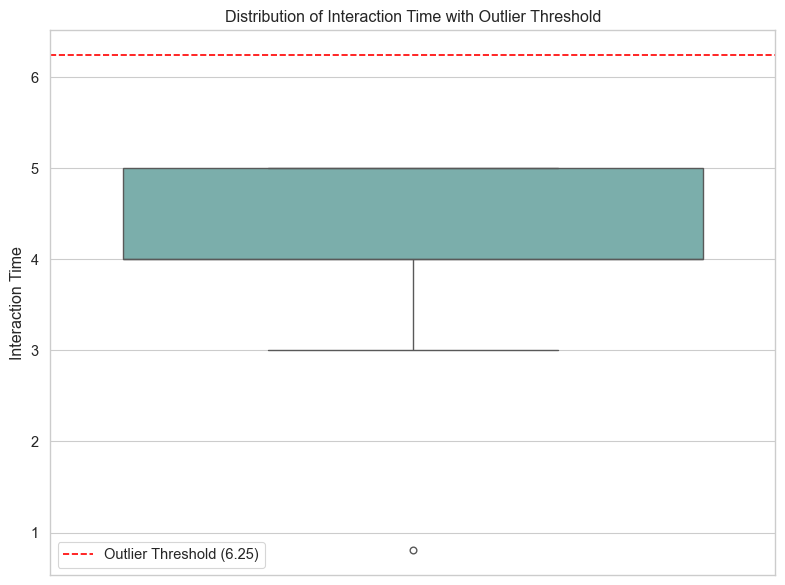

In [33]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure matplotlib plots display inline
%matplotlib inline

# Set Seaborn style for publication-ready plots
sns.set(style='whitegrid', context='paper', font_scale=1.2)

# Load the CSV
try:
    df = pd.read_csv('Responses - Post-Study Questionnaire - Correct Ones.csv')
except FileNotFoundError:
    print('Error: CSV file not found. Please ensure "Responses - Post-Study Questionnaire - Correct Ones.csv" is in the same directory or update the file path.')
    raise

# Remove empty rows
df = df.dropna(subset=['Timestamp'])

# Print column names for debugging
print('CSV Column Names:')
print(df.columns.tolist())

# Dynamically identify interaction time column
def find_column(columns, patterns, default=None):
    for pattern in patterns:
        for col in columns:
            if pattern.lower() in col.lower():
                return col
    print(f'Warning: No column found matching patterns {patterns}')
    return default

# Patterns for interaction time (e.g., Q4 or time-related)
time_patterns = ['quickly', 'time', 'duration']
time_col = find_column(df.columns, time_patterns, None)

# Check if interaction time column was found
if time_col is None:
    print('Error: No interaction time column found. Assuming Q4 as proxy (reverse-scored Likert scale).')
    time_col = find_column(df.columns, ['I was able to complete the tasks and scenarios quickly'], None)
    if time_col:
        # Reverse-score Q4 (Likert 1–5, lower means slower, so invert: 6 - score)
        df['Interaction_Time'] = 6 - pd.to_numeric(df[time_col], errors='coerce')
    else:
        print('Error: No suitable column for interaction time found. Analysis cannot proceed.')
        raise ValueError('No interaction time column available')
else:
    df['Interaction_Time'] = pd.to_numeric(df[time_col], errors='coerce')

# Drop rows with missing interaction time
df = df.dropna(subset=['Interaction_Time'])
if df.empty:
    print('Error: No valid interaction time data after cleaning.')
    raise ValueError('No valid interaction time data')

# Calculate mean and standard deviation
mean_time = df['Interaction_Time'].mean()
std_time = df['Interaction_Time'].std()
threshold = mean_time + 2 * std_time

# Identify outliers
outliers = df[df['Interaction_Time'] > threshold][['Timestamp', 'Interaction_Time']]
outliers = outliers.reset_index().rename(columns={'index': 'Respondent_ID'})

# Print results
print(f'\nMean Interaction Time: {mean_time:.2f}')
print(f'Standard Deviation: {std_time:.2f}')
print(f'Outlier Threshold (Mean + 2*SD): {threshold:.2f}')
print(f'Number of Outliers: {len(outliers)}')
if not outliers.empty:
    print('\nOutliers (Interaction Time > Mean + 2*SD):')
    print(outliers)
else:
    print('No outliers detected.')

# Visualize interaction time with boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Interaction_Time'], color='#72B7B2')
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Outlier Threshold ({threshold:.2f})')
plt.ylabel('Interaction Time')
plt.title('Distribution of Interaction Time with Outlier Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('interaction_time_boxplot.png', dpi=300)
plt.show()